<a href="https://colab.research.google.com/github/XinyueJianggg/credit-card-fraud/blob/main/ieee_cis_fraud_project_starter_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IEEE-CIS Credit-Card Fraud Detection
## Colab starter notebook for BankofJay

This notebook provides a leakage-aware framework for the semester project:

1. Load files from Google Drive.
2. Left join transaction and identity information.
3. Split the labeled data chronologically into 60% train, 20% validation, and 20% test.
4. Remove unusable features using training data only.
5. Fit three model groups:
   - class-weighted logistic regression;
   - balanced random forest;
   - CatBoost, LightGBM, and XGBoost with weighted soft voting.
6. Select ensemble weights and classification thresholds using validation data only.
7. Evaluate once on the untouched test period.
8. Export metrics, predictions, and feature importance.

**Important:** Kaggle's competition test files do not contain fraud labels. For the
academic comparison, this notebook splits Kaggle's labeled `train_transaction.csv`
chronologically. It does not use the Kaggle leaderboard as the project test set.


## Before the first run

Every teammate must do these steps once:

1. Sign in to Kaggle and accept the IEEE-CIS competition rules.
2. Downloads the two required CSV files
3. Create the folder "IEEE_CIS_Fraud" in Google Drive $\rightarrow$ My Drive
4. Upload `train_transaction.csv` and `train_identity.csv` to "IEEE_CIS_Fraud"


In [ ]:
!pip -q install catboost==1.2.10 lightgbm==4.7.0 xgboost==3.4.1 imbalanced-learn==0.14.2 scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 56.8 MB/s eta 0:00:00


For cell above: Rerunning is unnecessary during the same session, but must run it again after disconnection.

In [ ]:
#from google.colab import drive

#drive.mount("/content/drive", force_remount=True)

## 1. Access Data from Google Drive




In [ ]:
#do not need to remount Drive again during the same runtime.
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DATA_DIR = Path("/content/drive/MyDrive/IEEE_CIS_Fraud")

transaction_path = DATA_DIR / "train_transaction.csv"
identity_path = DATA_DIR / "train_identity.csv"

assert transaction_path.exists(), f"Cannot find {transaction_path}"
assert identity_path.exists(), f"Cannot find {identity_path}"

print("Transaction file:", transaction_path)
print("Identity file:", identity_path)

Mounted at /content/drive
Transaction file: /content/drive/MyDrive/IEEE_CIS_Fraud/train_transaction.csv
Identity file: /content/drive/MyDrive/IEEE_CIS_Fraud/train_identity.csv


In [ ]:
import gc
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
)

from imblearn.ensemble import BalancedRandomForestClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_theme(style="whitegrid")

SEED = 42
TARGET = "isFraud"
TIME_COLUMN = "TransactionDT"
ID_COLUMN = "TransactionID"

# Use True while testing the code.
# Change to False for the final full-data experiment.
FAST_MODE = True
FAST_TRAIN_ROWS = 150_000
FAST_VALID_ROWS = 60_000
FAST_TEST_ROWS = 60_000

N_TREES = 150 if FAST_MODE else 600

# Save results permanently in Google Drive.
OUTPUT_DIR = DATA_DIR / "project_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load and merge the data

The transaction table is the main table. A left join keeps every transaction, even
when no identity record exists. Missing identity information may itself be informative.


In [ ]:
transactions = pd.read_csv(transaction_path)
identity = pd.read_csv(identity_path)

data = transactions.merge(
    identity,
    on=ID_COLUMN,
    how="left",
    validate="one_to_one",
    indicator="identity_merge_status",
)
data["has_identity"] = (data["identity_merge_status"] == "both").astype("int8")
data = data.drop(columns="identity_merge_status")

print("Transaction table:", transactions.shape)
print("Identity table:", identity.shape)
print("Merged labeled data:", data.shape)
print("Fraud count:", int(data[TARGET].sum()))
print("Fraud rate:", f"{data[TARGET].mean():.3%}")
print("Transactions with identity data:", f"{data['has_identity'].mean():.3%}")

del transactions, identity


Transaction table: (590540, 394)
Identity table: (144233, 41)
Merged labeled data: (590540, 435)
Fraud count: 20663
Fraud rate: 3.499%
Transactions with identity data: 24.424%


##Data-merging summary:    

The transaction table contains 590,540 labeled transactions, while identity information is available for 144,233 transactions.      

We use a left join to all transaction records and this produces 435 columns, including the newly created has_identity indicator. Only 24.4% of transactions have matching identity information, so restricting the analysis to matched records would discard approximately 75.6% of the data.        

The dataset contains 20,663 fraudulent transactions, representing 3.5% of all observations, which confirms class imbalance.

## 3. Initial audit

Use this section for the proposal's data explanation and later report. The feature
counts below come from the actual merged data rather than a manually typed number.


Predictor columns before cleaning: 433
Object/category columns: 31
Other columns: 402


,missing_rate
id_24,0.991962
id_25,0.991310
id_07,0.991271
id_08,0.991271
id_21,0.991264
id_26,0.991257
id_23,0.991247
id_27,0.991247
id_22,0.991247
dist2,0.936284


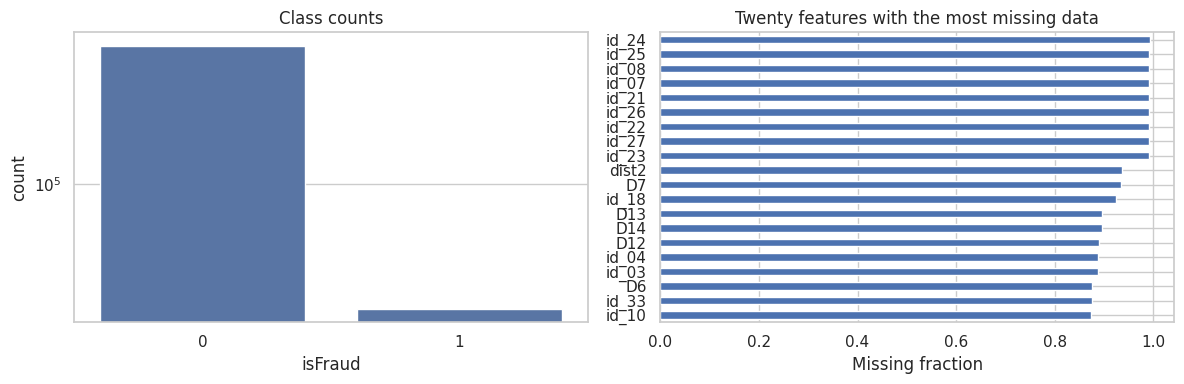

In [ ]:
feature_columns = [c for c in data.columns if c not in {TARGET, ID_COLUMN}]
object_columns = data[feature_columns].select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns_raw = [c for c in feature_columns if c not in object_columns]

print("Predictor columns before cleaning:", len(feature_columns))
print("Object/category columns:", len(object_columns))
print("Other columns:", len(numeric_columns_raw))

missing_summary = (
    data[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)
display(missing_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=TARGET, data=data, ax=axes[0])
axes[0].set_title("Class counts")
axes[0].set_yscale("log")
missing_summary.head(20).sort_values("missing_rate").plot.barh(
    y="missing_rate", legend=False, ax=axes[1]
)
axes[1].set_title("Twenty features with the most missing data")
axes[1].set_xlabel("Missing fraction")
plt.tight_layout()
plt.show()


##Initial feature assessment:     

The merged dataset contains 433 predictors: 31 stored as categorical/object variables and 402 stored as other data types.    

However, some numerically coded variables, such as card-related features, may still represent categories and will be reviewed before modeling.

Several identity features have over 99% missing values, partly because identity information exists for only 24.4% of transactions. Features with excessive missingness will be removed based only on the training set to prevent data leakage.

## 4. Chronological train, validation, and test split

Sorting by `TransactionDT` creates a more realistic experiment than a random split:
the models learn from earlier transactions and predict later transactions. The split
happens before imputation, encoding, feature selection, resampling, or model fitting.


In [ ]:
data = data.sort_values([TIME_COLUMN, ID_COLUMN]).reset_index(drop=True)
n_rows = len(data)
train_end = int(0.60 * n_rows)
valid_end = int(0.80 * n_rows)

train_df = data.iloc[:train_end].copy()
valid_df = data.iloc[train_end:valid_end].copy()
test_df = data.iloc[valid_end:].copy()
del data

def split_summary(name, frame):
    return {
        "split": name,
        "rows": len(frame),
        "fraud_count": int(frame[TARGET].sum()),
        "fraud_rate": frame[TARGET].mean(),
        "time_min": frame[TIME_COLUMN].min(),
        "time_max": frame[TIME_COLUMN].max(),
    }

display(pd.DataFrame([
    split_summary("train", train_df),
    split_summary("validation", valid_df),
    split_summary("test", test_df),
]))


,split,rows,fraud_count,fraud_rate,time_min,time_max
0,train,354324,11988,0.033833,86400,8745772
1,validation,118108,4611,0.039041,8745798,12192842
2,test,118108,4064,0.034409,12192900,15811131


In [ ]:
# Feature Engineering 1: Time-related features
time_features = [
    "DT_day", "DT_week", "DT_hour", "DT_dayofweek",
    "DT_hour_sin", "DT_hour_cos"
]

for frame in (train_df, valid_df, test_df):
    dt = pd.to_numeric(frame["TransactionDT"], errors="coerce")

    # TransactionDT is relative seconds, not a real calendar timestamp
    frame["DT_day"] = (dt // 86400).astype("float32")
    frame["DT_week"] = (dt // 604800).astype("float32")
    frame["DT_hour"] = ((dt // 3600) % 24).astype("float32")
    frame["DT_dayofweek"] = ((dt // 86400) % 7).astype("float32")

    frame["DT_hour_sin"] = np.sin(
        2 * np.pi * frame["DT_hour"] / 24
    ).astype("float32")
    frame["DT_hour_cos"] = np.cos(
        2 * np.pi * frame["DT_hour"] / 24
    ).astype("float32")

print("Time features:", time_features)
display(train_df[time_features].head())

## 5. Training-only feature filtering

Remove columns that are more than 95% missing in the training period or have only one
observed value there. Decisions made here use no validation or test information.


In [ ]:
excluded = {TARGET, ID_COLUMN}
candidate_features = [c for c in train_df.columns if c not in excluded]

train_missing_rate = train_df[candidate_features].isna().mean()
too_missing = train_missing_rate[train_missing_rate > 0.95].index.tolist()

remaining = [c for c in candidate_features if c not in too_missing]
constant_columns = [
    c for c in remaining
    if train_df[c].nunique(dropna=False) <= 1
]

selected_features = [
    c for c in remaining
    if c not in constant_columns
]

print("Starting predictors:", len(candidate_features))
print("Removed for >95% missing:", len(too_missing))
print("Removed as constant:", len(constant_columns))
print("Predictors retained:", len(selected_features))

X_train = train_df[selected_features].copy()
y_train = train_df[TARGET].astype("int8").copy()
X_valid = valid_df[selected_features].copy()
y_valid = valid_df[TARGET].astype("int8").copy()
X_test = test_df[selected_features].copy()
y_test = test_df[TARGET].astype("int8").copy()

test_metadata = test_df[[ID_COLUMN, TIME_COLUMN, "TransactionAmt"]].copy()
del train_df, valid_df, test_df


Starting predictors: 433
Removed for >95% missing: 9
Removed as constant: 1
Predictors retained: 423


## 6. Identify categorical columns

Some IEEE-CIS categorical fields are stored as numbers, so data type alone is not
enough. This list combines object columns with the categorical fields described by
the competition. Adjust it only after documenting the reason.


In [ ]:
documented_categorical = {
    "ProductCD",
    *[f"card{i}" for i in range(1, 7)],
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    *[f"M{i}" for i in range(1, 10)],
    "DeviceType", "DeviceInfo",
    *[f"id_{i:02d}" for i in range(12, 39)],
}

categorical_columns = [
    c for c in selected_features
    if c in documented_categorical
    or pd.api.types.is_object_dtype(X_train[c])
    or isinstance(X_train[c].dtype, pd.CategoricalDtype)
]
numeric_columns = [c for c in selected_features if c not in categorical_columns]

for frame in (X_train, X_valid, X_test):
    for column in categorical_columns:
        frame[column] = (
            frame[column]
            .astype("string")
            .fillna("__MISSING__")
            .astype(object)
        )
    frame[numeric_columns] = frame[numeric_columns].replace([np.inf, -np.inf], np.nan)

print("Categorical predictors used by preprocessing:", len(categorical_columns))
print("Numerical predictors used by preprocessing:", len(numeric_columns))
print("Total:", len(categorical_columns) + len(numeric_columns))


Categorical predictors used by preprocessing: 42
Numerical predictors used by preprocessing: 381
Total: 423


## 7. Optional fast-development sample

`FAST_MODE` samples only after the chronological split, so it does not mix future
transactions into the training period. Use it to test code. Set `FAST_MODE=False`
before producing final reported results.


In [ ]:
def stratified_subsample(X, y, maximum_rows, seed=SEED):
    if len(X) <= maximum_rows:
        return X, y
    rng = np.random.default_rng(seed)
    chosen = []
    for label in sorted(y.unique()):
        label_index = y.index[y == label].to_numpy()
        n_label = max(1, round(maximum_rows * len(label_index) / len(y)))
        chosen.append(rng.choice(label_index, size=min(n_label, len(label_index)), replace=False))
    chosen = np.concatenate(chosen)
    rng.shuffle(chosen)
    return X.loc[chosen].copy(), y.loc[chosen].copy()

if FAST_MODE:
    X_train, y_train = stratified_subsample(X_train, y_train, FAST_TRAIN_ROWS, SEED)
    X_valid, y_valid = stratified_subsample(X_valid, y_valid, FAST_VALID_ROWS, SEED + 1)
    X_test, y_test = stratified_subsample(X_test, y_test, FAST_TEST_ROWS, SEED + 2)
    test_metadata = test_metadata.loc[X_test.index].copy()

print("Rows used:", len(X_train), len(X_valid), len(X_test))
print("Fraud rates:", y_train.mean(), y_valid.mean(), y_test.mean())


Rows used: 150000 60000 60000
Fraud rates: 0.03383333333333333 0.03903333333333334 0.034416666666666665


## 8. Evaluation helpers

PR-AUC is the primary metric because fraud is rare. Threshold-dependent metrics use
a threshold selected on validation data, never on the final test period.


In [ ]:
def choose_f1_threshold(y_true, probability):
    precision, recall, thresholds = precision_recall_curve(y_true, probability)
    if len(thresholds) == 0:
        return 0.5
    f1_values = 2 * precision[:-1] * recall[:-1] / (
        precision[:-1] + recall[:-1] + 1e-12
    )
    return float(thresholds[int(np.nanargmax(f1_values))])

def metric_row(model_name, y_true, probability, threshold):
    prediction = (probability >= threshold).astype(int)
    return {
        "model": model_name,
        "PR_AUC": average_precision_score(y_true, probability),
        "ROC_AUC": roc_auc_score(y_true, probability),
        "accuracy": accuracy_score(y_true, prediction),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "threshold": threshold,
    }

validation_probabilities = {}
test_probabilities = {}
fitted_models = {}


## 9. Model 1: class-weighted logistic regression

Logistic regression is the linear baseline. One-hot encoding avoids treating category
codes as ordered quantities. `min_frequency` groups very rare categories to control
memory use. Class weighting makes errors on rare fraud cases count more during fitting.


In [ ]:
try:
    one_hot = OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=100,
        sparse_output=True,
    )
except TypeError:
    one_hot = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=100,
        sparse=True,
    )

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("one_hot", one_hot),
            ]),
            categorical_columns,
        ),
    ],
    sparse_threshold=1.0,
)

logistic_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            solver="saga",
            max_iter=300,
            random_state=SEED,
        ),
    ),
])

logistic_model.fit(X_train, y_train)
validation_probabilities["Weighted Logistic Regression"] = logistic_model.predict_proba(X_valid)[:, 1]
test_probabilities["Weighted Logistic Regression"] = logistic_model.predict_proba(X_test)[:, 1]
fitted_models["Weighted Logistic Regression"] = logistic_model


## 10. Shared tree preprocessing

Balanced random forest, LightGBM, and XGBoost use the same training-fitted numerical
matrix for a fair and memory-conscious comparison. Categories are ordinal-encoded,
but the tree models use splits rather than interpreting them as a linear distance.


In [ ]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_columns,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
                (
                    "ordinal",
                    OrdinalEncoder(
                        handle_unknown="use_encoded_value",
                        unknown_value=-1,
                        dtype=np.float32,
                    ),
                ),
            ]),
            categorical_columns,
        ),
    ],
)

X_train_tree = tree_preprocessor.fit_transform(X_train).astype("float32")
X_valid_tree = tree_preprocessor.transform(X_valid).astype("float32")
X_test_tree = tree_preprocessor.transform(X_test).astype("float32")

tree_feature_names = tree_preprocessor.get_feature_names_out()
print("Encoded tree matrix shapes:", X_train_tree.shape, X_valid_tree.shape, X_test_tree.shape)


Encoded tree matrix shapes: (150000, 423) (60000, 423) (60000, 423)


## 11. Model 2: balanced random forest

Each tree receives a balanced bootstrap sample. The trees learn independently, and
the forest averages their fraud probabilities.


In [ ]:
balanced_forest = BalancedRandomForestClassifier(
    n_estimators=N_TREES,
    random_state=SEED,
    n_jobs=-1,
    sampling_strategy="all",
    replacement=True,
    bootstrap=False,
)
balanced_forest.fit(X_train_tree, y_train)

validation_probabilities["Balanced Random Forest"] = balanced_forest.predict_proba(X_valid_tree)[:, 1]
test_probabilities["Balanced Random Forest"] = balanced_forest.predict_proba(X_test_tree)[:, 1]
fitted_models["Balanced Random Forest"] = balanced_forest


## 12. Model 3A: CatBoost

CatBoost receives the original categorical columns as strings. Numerical missing
values remain `NaN`, which CatBoost can handle. Its class weighting addresses the
imbalance without altering validation or test data.


In [ ]:
# The categorical columns were already converted to strings in Section 6.
# Reuse the existing frames to avoid three large in-memory copies.
X_train_cat = X_train
X_valid_cat = X_valid
X_test_cat = X_test

catboost_model = CatBoostClassifier(
    iterations=N_TREES,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    random_seed=SEED,
    allow_writing_files=False,
    verbose=50,
)

catboost_model.fit(
    X_train_cat,
    y_train,
    cat_features=categorical_columns,
    eval_set=(X_valid_cat, y_valid),
    use_best_model=True,
)

validation_probabilities["CatBoost"] = catboost_model.predict_proba(X_valid_cat)[:, 1]
test_probabilities["CatBoost"] = catboost_model.predict_proba(X_test_cat)[:, 1]
fitted_models["CatBoost"] = catboost_model

# LightGBM and XGBoost use the encoded arrays, so release the raw feature frames.
del X_train_cat, X_valid_cat, X_test_cat, X_train, X_valid, X_test
gc.collect()


0:	learn: 0.8397308	test: 0.8674563	best: 0.8674563 (0)	total: 2.02s	remaining: 5m 1s
50:	learn: 0.9178306	test: 0.9132374	best: 0.9132374 (50)	total: 50.7s	remaining: 1m 38s
100:	learn: 0.9305437	test: 0.9210375	best: 0.9210375 (100)	total: 1m 35s	remaining: 46.1s
149:	learn: 0.9393835	test: 0.9250744	best: 0.9250744 (149)	total: 2m 19s	remaining: 0us

bestTest = 0.9250744422
bestIteration = 149



0

## 13. Model 3B: LightGBM


In [ ]:
lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=N_TREES,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbosity=-1,
)

lightgbm_model.fit(
    X_train_tree,
    y_train,
    eval_set=[(X_valid_tree, y_valid)],
    eval_metric="average_precision",
    callbacks=[lgb.early_stopping(40, verbose=False)],
)

validation_probabilities["LightGBM"] = lightgbm_model.predict_proba(X_valid_tree)[:, 1]
test_probabilities["LightGBM"] = lightgbm_model.predict_proba(X_test_tree)[:, 1]
fitted_models["LightGBM"] = lightgbm_model


## 14. Model 3C: XGBoost


In [ ]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

xgboost_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    n_estimators=N_TREES,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=5,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
)

xgboost_model.fit(
    X_train_tree,
    y_train,
    eval_set=[(X_valid_tree, y_valid)],
    verbose=False,
)

validation_probabilities["XGBoost"] = xgboost_model.predict_proba(X_valid_tree)[:, 1]
test_probabilities["XGBoost"] = xgboost_model.predict_proba(X_test_tree)[:, 1]
fitted_models["XGBoost"] = xgboost_model


## 15. Weighted soft-voting ensemble

A small grid search chooses nonnegative weights that sum to one and maximize validation
PR-AUC. The test labels are not used. This combines probabilities; it does not choose
a different winning model for each transaction.


In [ ]:
ensemble_members = ["CatBoost", "LightGBM", "XGBoost"]

def select_soft_voting_weights(y_true, probability_dict, steps=10):
    best_score = -np.inf
    best_weights = None
    for cat_units in range(steps + 1):
        for light_units in range(steps + 1 - cat_units):
            xgb_units = steps - cat_units - light_units
            weights = np.array([cat_units, light_units, xgb_units], dtype=float) / steps
            combined = sum(
                weight * probability_dict[name]
                for weight, name in zip(weights, ensemble_members)
            )
            score = average_precision_score(y_true, combined)
            if score > best_score:
                best_score = score
                best_weights = weights
    return best_weights, best_score

ensemble_weights, ensemble_validation_pr_auc = select_soft_voting_weights(
    y_valid,
    validation_probabilities,
)

ensemble_validation_probability = sum(
    weight * validation_probabilities[name]
    for weight, name in zip(ensemble_weights, ensemble_members)
)
ensemble_test_probability = sum(
    weight * test_probabilities[name]
    for weight, name in zip(ensemble_weights, ensemble_members)
)

validation_probabilities["Weighted Boosting Ensemble"] = ensemble_validation_probability
test_probabilities["Weighted Boosting Ensemble"] = ensemble_test_probability

weight_table = pd.DataFrame({
    "model": ensemble_members,
    "weight": ensemble_weights,
})
display(weight_table)
print("Validation PR-AUC:", ensemble_validation_pr_auc)


,model,weight
0,CatBoost,0.3
1,LightGBM,0.5
2,XGBoost,0.2


Validation PR-AUC: 0.5758187502419999


## 16. Validation summary and threshold selection

This table is the appropriate place to compare development results. Each threshold
maximizes F1 on validation data. If the project prioritizes recall or a maximum false
alert rate, replace the threshold rule and document that decision.


In [ ]:
selected_thresholds = {
    name: choose_f1_threshold(y_valid, probability)
    for name, probability in validation_probabilities.items()
}

validation_results = pd.DataFrame([
    metric_row(name, y_valid, probability, selected_thresholds[name])
    for name, probability in validation_probabilities.items()
]).sort_values("PR_AUC", ascending=False)

display(validation_results)


,model,PR_AUC,ROC_AUC,accuracy,precision,recall,F1,threshold
5,Weighted Boosting Ensemble,0.575819,0.918415,0.968033,0.611579,0.496157,0.547855,0.759307
3,LightGBM,0.564046,0.913464,0.969917,0.668339,0.455167,0.541529,0.823550
4,XGBoost,0.552874,0.907900,0.970283,0.681141,0.448762,0.541055,0.789555
2,CatBoost,0.539678,0.905771,0.966933,0.596757,0.471392,0.526718,0.808155
1,Balanced Random Forest,0.521517,0.896814,0.964817,0.559383,0.464560,0.507581,0.686667
0,Weighted Logistic Regression,0.452864,0.871430,0.961683,0.511382,0.412468,0.456630,0.888259


## 17. Final test evaluation

Run this only after the model settings, ensemble weights, and thresholds have been
finalized using training and validation data. Report PR-AUC as the primary metric;
accuracy can be included only as a secondary metric because of the imbalance.


,model,PR_AUC,ROC_AUC,accuracy,precision,recall,F1,threshold
5,Weighted Boosting Ensemble,0.468130,0.884178,0.965317,0.495526,0.429056,0.459901,0.759307
4,XGBoost,0.460757,0.871708,0.969500,0.586207,0.386925,0.466161,0.789555
3,LightGBM,0.457985,0.873418,0.968317,0.555256,0.399031,0.464356,0.823550
1,Balanced Random Forest,0.435321,0.870548,0.963550,0.465884,0.403390,0.432390,0.686667
2,CatBoost,0.431332,0.873195,0.963983,0.472665,0.401937,0.434441,0.808155
0,Weighted Logistic Regression,0.177849,0.823569,0.936933,0.250073,0.416465,0.312500,0.888259


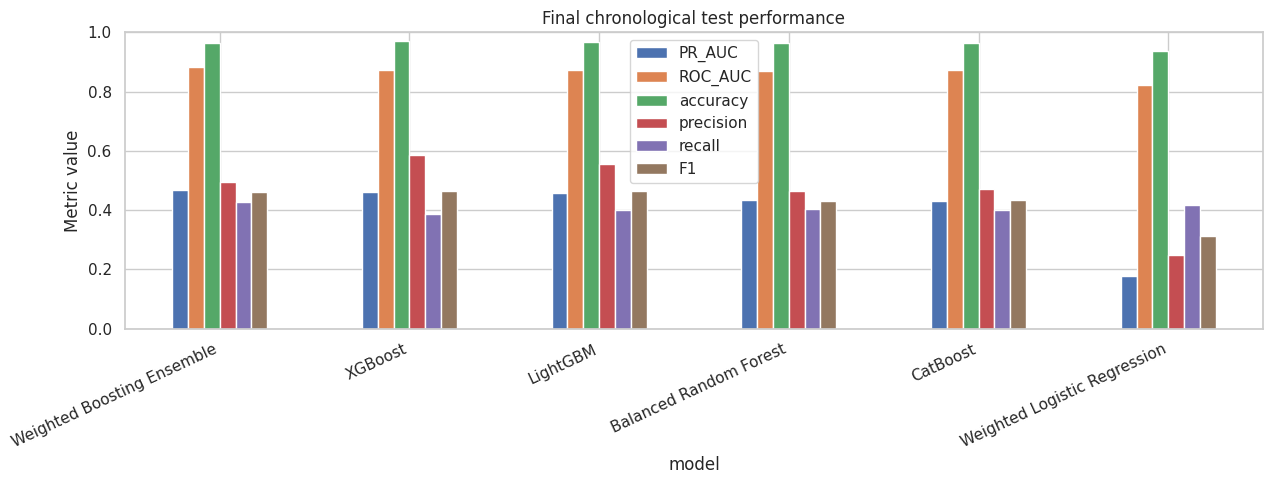

In [ ]:
test_results = pd.DataFrame([
    metric_row(name, y_test, probability, selected_thresholds[name])
    for name, probability in test_probabilities.items()
]).sort_values("PR_AUC", ascending=False)

display(test_results)

comparison = test_results.set_index("model")[["PR_AUC", "ROC_AUC", "accuracy", "precision", "recall", "F1"]]
comparison.plot.bar(figsize=(13, 5))
plt.title("Final chronological test performance")
plt.ylabel("Metric value")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 18. Confusion matrix for the final ensemble


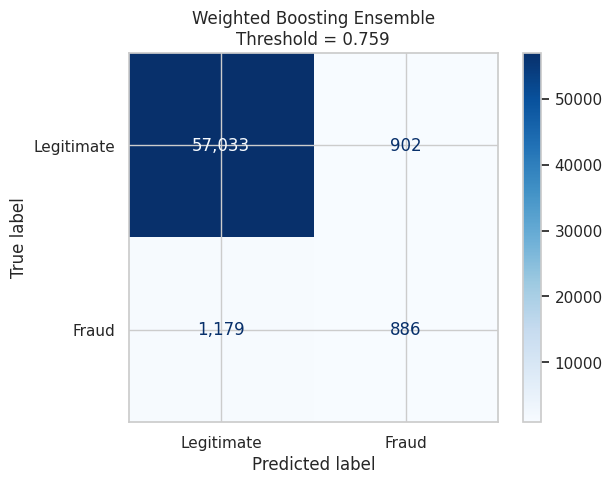

In [ ]:
final_name = "Weighted Boosting Ensemble"
final_threshold = selected_thresholds[final_name]
final_prediction = (test_probabilities[final_name] >= final_threshold).astype(int)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, final_prediction),
    display_labels=["Legitimate", "Fraud"],
).plot(cmap="Blues", values_format=",d")
plt.title(f"{final_name}\nThreshold = {final_threshold:.3f}")
plt.show()


## 19. LightGBM feature importance

This is a first interpretation step, not a causal explanation. Later, the team can add
permutation importance or SHAP using a manageable sample of validation transactions.


,feature,importance
0,numeric__TransactionDT,468
382,categorical__card1,458
1,numeric__TransactionAmt,391
383,categorical__card2,380
388,categorical__addr1,311
16,numeric__C13,288
4,numeric__C1,196
386,categorical__card5,193
27,numeric__D10,192
19,numeric__D2,172


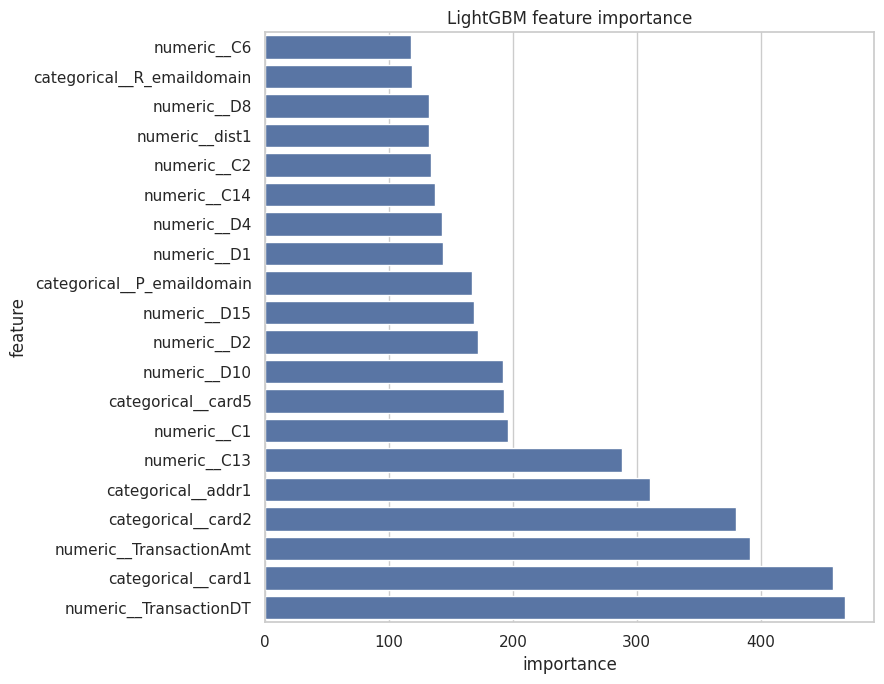

In [ ]:
importance = pd.DataFrame({
    "feature": tree_feature_names,
    "importance": lightgbm_model.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance.head(25))

plt.figure(figsize=(9, 7))
sns.barplot(
    data=importance.head(20).sort_values("importance"),
    x="importance",
    y="feature",
)
plt.title("LightGBM feature importance")
plt.tight_layout()
plt.show()


## 20. Error analysis

Review high-confidence false positives and false negatives. This can reveal data-quality
issues, unstable patterns, or groups of transactions that need additional features.


In [ ]:
error_analysis = test_metadata.copy()
error_analysis["actual"] = y_test
error_analysis["fraud_probability"] = test_probabilities[final_name]
error_analysis["predicted"] = final_prediction

false_positives = error_analysis.query("actual == 0 and predicted == 1").sort_values(
    "fraud_probability", ascending=False
)
false_negatives = error_analysis.query("actual == 1 and predicted == 0").sort_values(
    "fraud_probability", ascending=True
)

print("Highest-confidence false positives")
display(false_positives.head(10))
print("Lowest-scored missed fraud cases")
display(false_negatives.head(10))


Highest-confidence false positives


,TransactionID,TransactionDT,TransactionAmt,actual,fraud_probability,predicted
529628,3516628,13947981,15.247,0,0.996099,1
582342,3569342,15550017,78.387,0,0.995882,1
529621,3516621,13947451,15.247,0,0.994213,1
531631,3518631,13993670,30.494,0,0.993838,1
529620,3516620,13947392,15.247,0,0.993591,1
536870,3523870,14150271,20.903,0,0.993154,1
492342,3479342,12851073,6.394,0,0.991686,1
538592,3525592,14208879,15.247,0,0.990929,1
558847,3545847,14786929,9.468,0,0.990346,1
558848,3545848,14787015,9.468,0,0.990297,1


Lowest-scored missed fraud cases


,TransactionID,TransactionDT,TransactionAmt,actual,fraud_probability,predicted
505522,3492522,13227323,30.950,1,0.036175,0
552897,3539897,14602296,47.950,1,0.046567,0
503309,3490309,13192113,25.000,1,0.047251,0
529426,3516426,13923578,57.950,1,0.048456,0
496262,3483262,12971502,36.950,1,0.053920,0
503568,3490568,13195906,57.950,1,0.055492,0
549703,3536703,14511241,57.950,1,0.059672,0
554110,3541110,14656178,34.921,1,0.061401,0
568668,3555668,15091488,47.950,1,0.062863,0
480637,3467637,12498128,29.950,1,0.067614,0


## 21. Optional SMOTE+ENN experiment

Leave this off during the first implementation. SMOTE+ENN is expensive on this large,
high-dimensional dataset. It must operate on training data only. `SMOTENC` is used for
categorical positions so that synthetic samples do not interpolate category codes as
though they were continuous measurements. For the report, compare this experiment with
class weighting while keeping the same validation and test periods.


In [ ]:
RUN_SMOTEENN = False

if RUN_SMOTEENN:
    from imblearn.combine import SMOTEENN
    from imblearn.over_sampling import SMOTENC
    from imblearn.under_sampling import EditedNearestNeighbours

    categorical_positions = list(
        range(len(numeric_columns), len(numeric_columns) + len(categorical_columns))
    )
    smote_nc = SMOTENC(
        categorical_features=categorical_positions,
        sampling_strategy=0.25,
        random_state=SEED,
    )
    sampler = SMOTEENN(
        smote=smote_nc,
        enn=EditedNearestNeighbours(n_jobs=-1),
        random_state=SEED,
        n_jobs=-1,
    )
    X_train_resampled, y_train_resampled = sampler.fit_resample(
        X_train_tree,
        y_train,
    )
    print("Before:", X_train_tree.shape, y_train.value_counts().to_dict())
    print("After:", X_train_resampled.shape, pd.Series(y_train_resampled).value_counts().to_dict())
else:
    print("SMOTE+ENN skipped. Set RUN_SMOTEENN=True after the main pipeline works.")


SMOTE+ENN skipped. Set RUN_SMOTEENN=True after the main pipeline works.


## 22. Save reproducible outputs

Save the split settings, retained features, ensemble weights, thresholds, metrics, and
predictions. These are small enough to share with teammates or commit to a project
repository. Do not commit Kaggle data or private API tokens.
